In [4]:
# Import necessary libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
# Load California Housing Dataset

housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["Price"] = housing.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Shape of dataset
print(df.shape)

# Information
df.info()

# Statistical summary
df.describe()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Missing values

df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


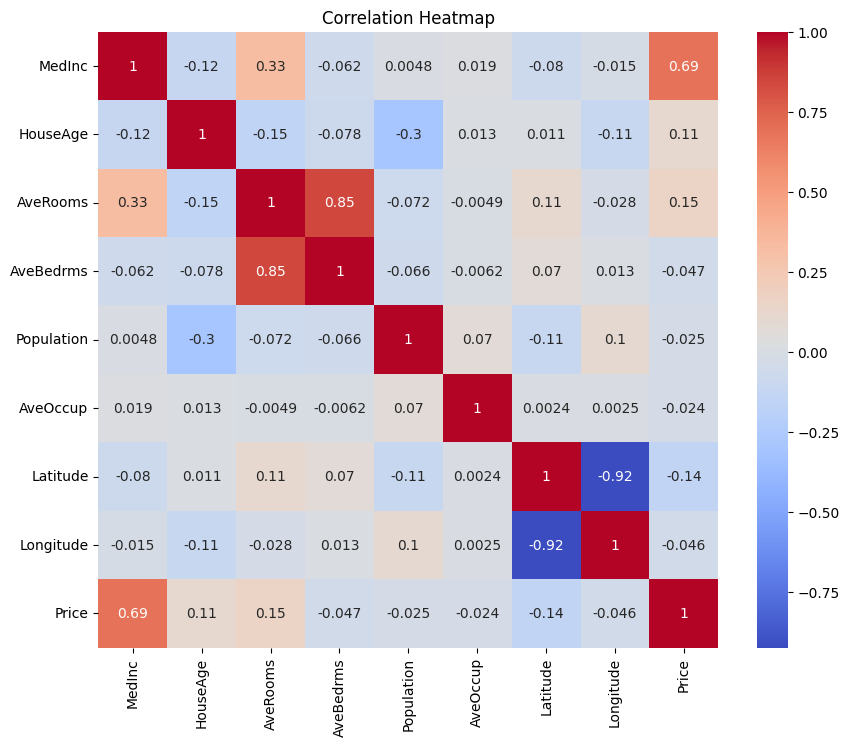

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Features
X = df.drop("Price", axis=1)

# Target
y = df["Price"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [12]:
predictions = model.predict(X_test)

predictions[:5]

array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725])

In [13]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R² Score: 0.5757877060324508


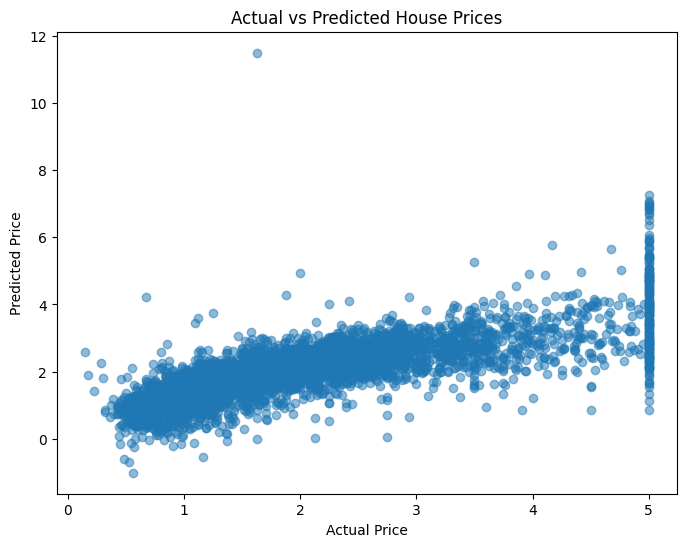

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [15]:
import pandas as pd

new_houses = pd.DataFrame([
    [8.0, 25, 6.0, 1.2, 800, 3.0, 37.5, -122.0],
    [5.5, 15, 5.0, 1.0, 1200, 2.8, 34.2, -118.4],
    [3.0, 40, 4.0, 1.5, 600, 2.0, 36.7, -119.5]
], columns=X.columns)

predicted_prices = model.predict(new_houses)

print(predicted_prices)

[4.16702487 2.73864897 1.80660041]


FileNotFoundError: [Errno 2] No such file or directory: 'images/price_distribution.png'

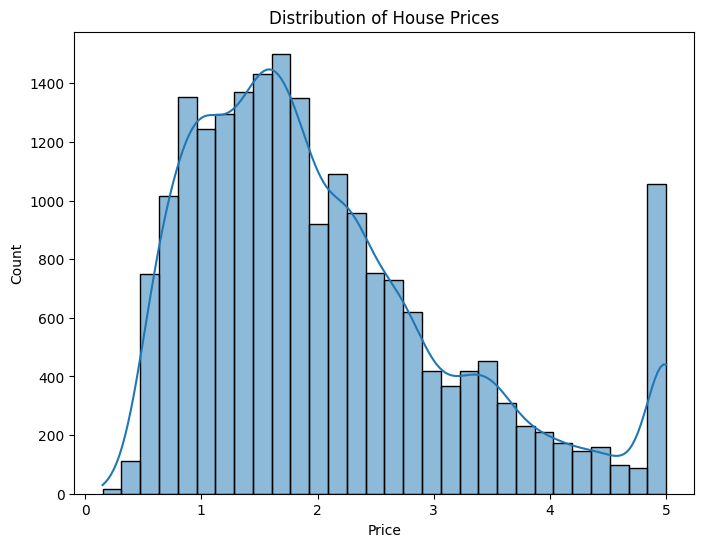

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")

plt.savefig("images/price_distribution.png")
plt.show()

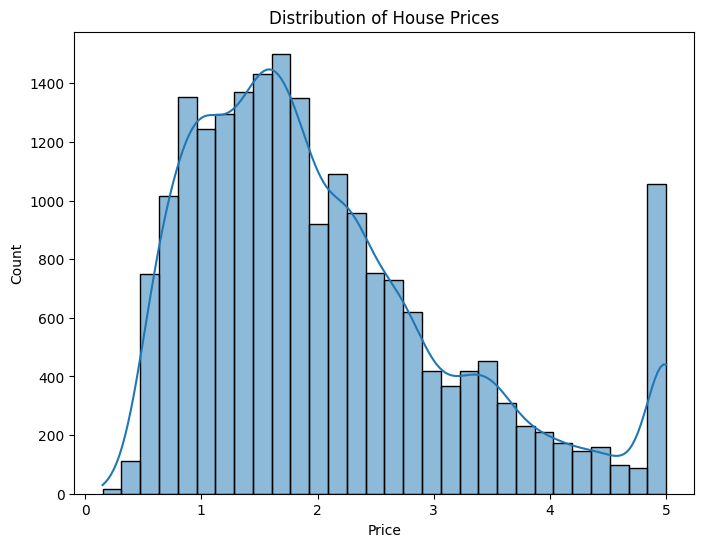

In [19]:
import os

plt.figure(figsize=(8,6))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")

# Create the 'images' directory if it doesn't exist
output_dir = "images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, "price_distribution.png"))
plt.show()